In [15]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.robust import mad

train_data = pd.read_csv('Datasets/DailyDelhiClimateTrain.csv', index_col='date', parse_dates=True)
test_data = pd.read_csv('Datasets/DailyDelhiClimateTest.csv', index_col='date', parse_dates=True)

In [16]:
def outlier_removal(df, period=365, lb=700, ub=1320, verbose=False):
    series = df['meanpressure']
    stl = STL(series, period=period)
    res = stl.fit()

    residuals = res.resid

    resid_mad = mad(residuals)
    outlier_mask = abs(residuals) > 3 * resid_mad
    outlier_mask &= (series < lb) | (series > ub)

    clean_series = series.copy()
    clean_series[outlier_mask] = float('nan')
    clean_series = clean_series.interpolate()
    
    # If some value is nan at the start or end, fill it with nearest valid value
    clean_series.fillna(method='bfill', inplace=True)
    clean_series.fillna(method='ffill', inplace=True)

    df['meanpressure'] = clean_series
    
    if verbose:
        fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

        ax[0].plot(series, label='Original', linewidth=1)
        ax[0].scatter(series.index[outlier_mask], series[outlier_mask], 
                    color='red', s=15, label='Outliers')
        ax[0].set_title("Mean Pressure — Original with Outliers")
        ax[0].legend()

        ax[1].plot(clean_series, label='Cleaned', linewidth=1)
        ax[1].set_title("Mean Pressure — After Outlier Handling")
        ax[1].legend()

        plt.tight_layout()
        plt.show()

outlier_removal(train_data)
outlier_removal(test_data, period=57)

C:\Users\anton\AppData\Local\Temp\ipykernel_13712\3446335051.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  clean_series.fillna(method='bfill', inplace=True)
C:\Users\anton\AppData\Local\Temp\ipykernel_13712\3446335051.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  clean_series.fillna(method='ffill', inplace=True)
C:\Users\anton\AppData\Local\Temp\ipykernel_13712\3446335051.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  clean_series.fillna(method='bfill', inplace=True)
C:\Users\anton\AppData\Local\Temp\ipykernel_13712\3446335051.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  clean_series.fillna(method='ffill', in

In [17]:
train_values = train_data.values
test_values = test_data.values

T = 7
H = 7
humidity_idx = train_data.columns.get_loc('humidity')

def make_dataset_multistep(values, T, H, humidity_idx):
    X, Y = [], []
    for t in range(len(values) - T - H + 1):
        X.append(values[t:t+T])
        Y.append([values[t+T + h][humidity_idx] for h in range(H)])
    return np.array(X), np.array(Y)

In [18]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_values)
test_scaled  = scaler.transform(test_values)

X_train, Y_train = make_dataset_multistep(train_scaled, T, H, humidity_idx)
X_test,  Y_test  = make_dataset_multistep(test_scaled,  T, H, humidity_idx)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: (1449, 7, 4)
Y_train shape: (1449, 7)


In [19]:
n_features = train_values.shape[1]

lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(T, n_features), return_sequences=False),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(H)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, Y_train, epochs=300, batch_size=64, verbose=1)

Epoch 1/300


c:\Users\anton\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.8657
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6347
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4984
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4392
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4231
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4129
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4070
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4016
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3958
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3997
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3902
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3873
Epoch 13/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3831
Epoch 14/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3816
Epoch 15/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3782
Epoch 16/300
23

In [20]:
test_loss = lstm_model.evaluate(X_test, Y_test, batch_size=64, verbose=1)
print("Test Loss (MSE):", test_loss)

def inverse_humidity_multi(preds_scaled, scaler, humidity_idx, n_features):
    n_samples, Hloc = preds_scaled.shape
    preds_orig = np.zeros((n_samples, Hloc))
    for h in range(Hloc):
        tmp = np.zeros((n_samples, n_features))
        tmp[:, humidity_idx] = preds_scaled[:, h]
        inv = scaler.inverse_transform(tmp)
        preds_orig[:, h] = inv[:, humidity_idx]
    return preds_orig

n_features = train_values.shape[1]
n_test_days = test_scaled.shape[0]

history = [row.copy() for row in train_scaled[-T:]]
preds_scaled_list = []

day_idx = 0
while day_idx < n_test_days:
    inp = np.array(history[-T:]).reshape(1, T, n_features)
    block_pred_scaled = lstm_model.predict(inp)[0]
    
    for h in range(H):
        if day_idx >= n_test_days:
            break
        row = test_scaled[day_idx].copy()
        row[humidity_idx] = block_pred_scaled[h]
        history.append(row)
        preds_scaled_list.append(block_pred_scaled[h])
        day_idx += 1

preds_scaled_array = np.array(preds_scaled_list).reshape(-1, 1)
preds_orig = inverse_humidity_multi(preds_scaled_array, scaler, humidity_idx, n_features).ravel()

true_humidity = test_data['humidity'].values

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.5873 
Test Loss (MSE): 0.5873261094093323
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


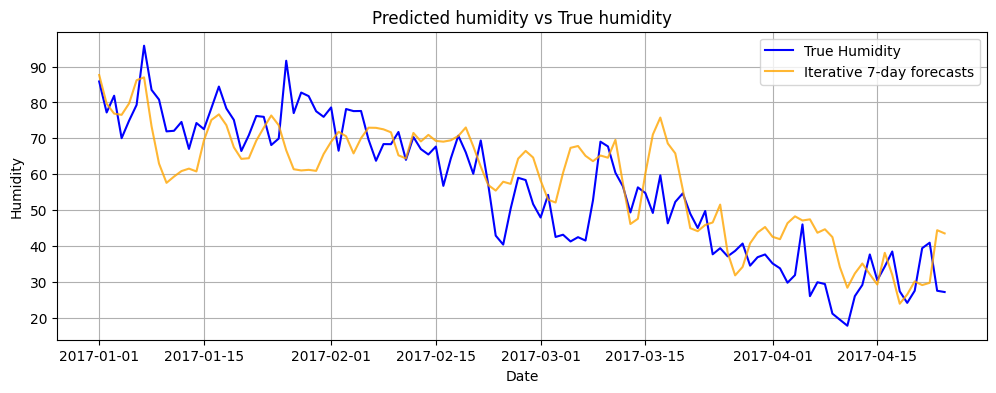

In [21]:
plt.figure(figsize=(12,4))
plt.plot(test_data.index, true_humidity, label='True Humidity', color='blue')
plt.plot(test_data.index, preds_orig, label='Iterative 7-day forecasts', color='orange', alpha=0.8)
plt.title('Predicted humidity vs True humidity')
plt.xlabel('Date')
plt.ylabel('Humidity')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
rmse = np.sqrt(mean_squared_error(true_humidity, preds_orig))
mae  = mean_absolute_error(true_humidity, preds_orig)
print(f"Iterative forecast RMSE: {rmse:.3f}")
print(f"Iterative forecast MAE : {mae:.3f}")


Iterative forecast RMSE: 10.900
Iterative forecast MAE : 8.868
